In [88]:
# =========================================================
# SEASONAL WEATHER PREDICTION - FULL CODE
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import json

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [89]:
# =========================================================
# 1) LOAD DATA
# =========================================================
df = pd.read_csv("weatherData.csv")

# Clean column names
df.columns = (
    df.columns.astype(str)
    .str.strip()
    .str.replace(r"\s+", "_", regex=True)
    .str.replace(r"[^\w_]", "", regex=True)
)

print("Loaded dataset shape:", df.shape)
print("Columns:")
print(df.columns.tolist())

Loaded dataset shape: (142371, 21)
Columns:
['location_id', 'date', 'weather_code_wmo_code', 'temperature_2m_max_C', 'temperature_2m_min_C', 'temperature_2m_mean_C', 'apparent_temperature_max_C', 'apparent_temperature_min_C', 'apparent_temperature_mean_C', 'daylight_duration_s', 'sunshine_duration_s', 'precipitation_sum_mm', 'rain_sum_mm', 'precipitation_hours_h', 'wind_speed_10m_max_kmh', 'wind_gusts_10m_max_kmh', 'wind_direction_10m_dominant_', 'shortwave_radiation_sum_MJm²', 'et0_fao_evapotranspiration_mm', 'sunrise', 'sunset']


In [90]:
# =========================================================
# 2) AUTO-DETECT IMPORTANT COLUMNS
# =========================================================

# ---- Detect date column ----
date_like_cols = [c for c in df.columns if any(k in c.lower() for k in ["date", "time", "timestamp", "datetime"])]
DATE_COL = None
best_ratio = 0

for c in date_like_cols:
    parsed = pd.to_datetime(df[c], errors="coerce")
    ratio = parsed.notna().mean()
    if ratio > best_ratio:
        best_ratio = ratio
        DATE_COL = c

if DATE_COL is None:
    raise ValueError(f"No date-like column found. Tried: {date_like_cols}")

df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce")
print(f"\nUsing DATE_COL = {DATE_COL} (parse success = {best_ratio:.2f})")


Using DATE_COL = date (parse success = 1.00)


In [91]:
# ---- Detect location column ----
LOC_CANDIDATES = ["location_id", "location", "city", "station", "station_id", "district", "region"]
LOC_COL = next((c for c in LOC_CANDIDATES if c in df.columns), None)

if LOC_COL is None:
    raise ValueError(f"No location column found. Tried: {LOC_CANDIDATES}")

df[LOC_COL] = df[LOC_COL].astype(str)
print(f"Using LOC_COL = {LOC_COL}")

Using LOC_COL = location_id


In [92]:
# ---- Helper for target detection ----
def pick_col_by_keywords(keywords):
    candidates = []
    for c in df.columns:
        cl = c.lower()
        if any(k in cl for k in keywords):
            candidates.append(c)
    return candidates

In [93]:
# ---- Detect temperature column ----
temp_candidates = pick_col_by_keywords([
    "temperature_2m_mean",
    "temp_mean",
    "temperature_mean",
    "temperature",
    "temp"
])
# ---- Detect rainfall column ----
rain_candidates = pick_col_by_keywords([
    "precipitation_sum",
    "rain_sum",
    "rainfall",
    "precipitation",
    "rain"
])

# ---- Detect sunshine column ----
sun_candidates = pick_col_by_keywords([
    "sunshine_duration",
    "sunshine",
    "sun_hours",
    "sunlight"
])

In [94]:
print("\nTarget candidates:")
print("Temperature:", temp_candidates[:10])
print("Rainfall   :", rain_candidates[:10])
print("Sunshine   :", sun_candidates[:10])


Target candidates:
Temperature: ['temperature_2m_max_C', 'temperature_2m_min_C', 'temperature_2m_mean_C', 'apparent_temperature_max_C', 'apparent_temperature_min_C', 'apparent_temperature_mean_C']
Rainfall   : ['precipitation_sum_mm', 'rain_sum_mm', 'precipitation_hours_h']
Sunshine   : ['sunshine_duration_s']


In [95]:
if not temp_candidates:
    raise ValueError("No temperature column detected.")
if not rain_candidates:
    raise ValueError("No rainfall column detected.")
if not sun_candidates:
    raise ValueError("No sunshine column detected.")

TEMP_COL = temp_candidates[0]
RAIN_COL = rain_candidates[0]
SUN_COL = sun_candidates[0]

print(f"\nUsing TEMP_COL = {TEMP_COL}")
print(f"Using RAIN_COL = {RAIN_COL}")
print(f"Using SUN_COL  = {SUN_COL}")


Using TEMP_COL = temperature_2m_max_C
Using RAIN_COL = precipitation_sum_mm
Using SUN_COL  = sunshine_duration_s


In [96]:
# =========================================================
# 3) BASIC CLEANING
# =========================================================
missing_tokens = ["NA", "N/A", "na", "n/a", "null", "NULL", "None", "none", "-", "--", " "]
df = df.replace(missing_tokens, np.nan)

dup_count = df.duplicated().sum()
print("\nDuplicate rows:", dup_count)

if dup_count > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print("Duplicates removed. New shape:", df.shape)


Duplicate rows: 0


In [97]:
# =========================================================
# 4) CREATE TIME FEATURES
# =========================================================
df = df.dropna(subset=[DATE_COL, LOC_COL]).copy()

df["year"] = df[DATE_COL].dt.year
df["month"] = df[DATE_COL].dt.month
df["day_of_year"] = df[DATE_COL].dt.dayofyear

df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)


In [98]:
# =========================================================
# 5) CREATE SRI LANKAN SEASON COLUMN
# =========================================================
# Based on your rainfall season screenshot:
# 1. South-west monsoon period (May to September)
# 2. Intermonsoon period following the South-west monsoon (October to November)
# 3. North-east monsoon period (December to February)
# 4. Intermonsoon period following the North-east monsoon (March to April)

def get_sri_lanka_season(month):
    if month in [5, 6, 7, 8, 9]:
        return "South-west monsoon"
    elif month in [10, 11]:
        return "Intermonsoon after South-west monsoon"
    elif month in [12, 1, 2]:
        return "North-east monsoon"
    elif month in [3, 4]:
        return "Intermonsoon after North-east monsoon"
    return "Unknown"

df["season"] = df["month"].apply(get_sri_lanka_season)

print("\nSeason distribution:")
print(df["season"].value_counts(dropna=False))


Season distribution:
South-west monsoon                       58887
North-east monsoon                       35721
Intermonsoon after North-east monsoon    24705
Intermonsoon after South-west monsoon    23058
Name: season, dtype: int64


In [99]:
# =========================================================
# 6) CONVERT TARGETS TO NUMERIC
# =========================================================
df[TEMP_COL] = pd.to_numeric(df[TEMP_COL], errors="coerce")
df[RAIN_COL] = pd.to_numeric(df[RAIN_COL], errors="coerce")
df[SUN_COL] = pd.to_numeric(df[SUN_COL], errors="coerce")

# Convert sunshine to hours if stored in seconds
SUN_H_COL = "sunshine_h"
if "duration" in SUN_COL.lower() and SUN_COL.lower().endswith("_s"):
    df[SUN_H_COL] = df[SUN_COL] / 3600.0
else:
    df[SUN_H_COL] = df[SUN_COL]

df = df.dropna(subset=[TEMP_COL, RAIN_COL, SUN_H_COL]).copy()

print("\nShape after target cleaning:", df.shape)


Shape after target cleaning: (142371, 28)


In [100]:
# =========================================================
# 7) AGGREGATE DAILY DATA -> SEASONAL DATA
# =========================================================
# For farming, we need seasonal weather rather than one-day weather.
# Seasonal rainfall = SUM
# Seasonal temperature = MEAN
# Seasonal sunshine = MEAN

seasonal_df = df.groupby(
    ["year", "season", LOC_COL],
    as_index=False
).agg({
    TEMP_COL: "mean",
    RAIN_COL: "sum",
    SUN_H_COL: "mean"
})

seasonal_df = seasonal_df.rename(columns={
    TEMP_COL: "avg_temperature_C",
    RAIN_COL: "total_rainfall_mm",
    SUN_H_COL: "avg_sunshine_h"
})

# Log transform rainfall to reduce skewness
seasonal_df["log_total_rainfall_mm"] = np.log1p(seasonal_df["total_rainfall_mm"])

print("\nSeasonal dataset shape:", seasonal_df.shape)
print(seasonal_df.head())

seasonal_df = seasonal_df.sort_values([LOC_COL, "year"])

seasonal_df["prev_season_rainfall"] = seasonal_df.groupby(LOC_COL)["total_rainfall_mm"].shift(1)

seasonal_df = seasonal_df.dropna()


Seasonal dataset shape: (1593, 7)
   year                                 season location_id  avg_temperature_C  \
0  2010  Intermonsoon after North-east monsoon           0          31.598361   
1  2010  Intermonsoon after North-east monsoon           1          32.132787   
2  2010  Intermonsoon after North-east monsoon          10          33.262295   
3  2010  Intermonsoon after North-east monsoon          11          32.095082   
4  2010  Intermonsoon after North-east monsoon          12          34.003279   

   total_rainfall_mm  avg_sunshine_h  log_total_rainfall_mm  
0              321.8        9.970940               5.777033  
1              323.3       10.051810               5.781669  
2               60.2       11.080850               4.114147  
3              102.3       11.032936               4.637637  
4              140.6       10.792193               4.953006  


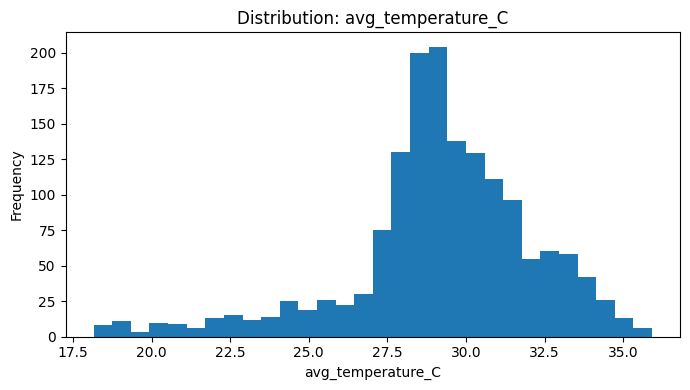

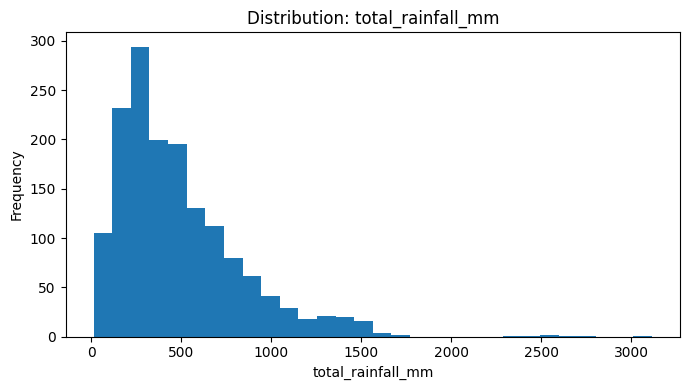

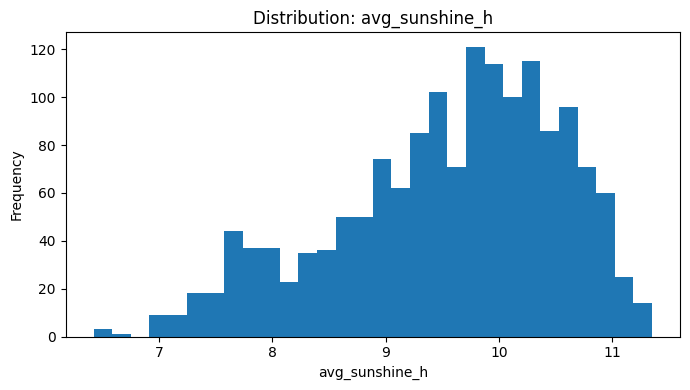

In [101]:
# =========================================================
# 8) OPTIONAL VISUAL CHECKS
# =========================================================
for col in ["avg_temperature_C", "total_rainfall_mm", "avg_sunshine_h"]:
    plt.figure(figsize=(7, 4))
    seasonal_df[col].dropna().plot(kind="hist", bins=30)
    plt.title(f"Distribution: {col}")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

In [102]:
# =========================================================
# 9) INPUT FEATURES
# =========================================================
X = seasonal_df[[LOC_COL, "season", "year", "prev_season_rainfall"]]
print("\nFeature sample:")
print(X.head())


Feature sample:
    location_id                                 season  year  \
27            0  Intermonsoon after South-west monsoon  2010   
54            0                     North-east monsoon  2010   
81            0                     South-west monsoon  2010   
108           0  Intermonsoon after North-east monsoon  2011   
135           0  Intermonsoon after South-west monsoon  2011   

     prev_season_rainfall  
27                  321.8  
54                  777.2  
81                  567.2  
108                1423.7  
135                 391.8  


In [103]:
# =========================================================
# 10) FUNCTION TO TRAIN ONE SEASONAL TARGET MODEL
# =========================================================
def train_and_evaluate_model(X, y, target_name, is_log_target=False):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    preprocess = ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore"), [LOC_COL, "season"]),
        ("num", "passthrough", ["year"])
    ])

    model = Pipeline([
        ("preprocess", preprocess),
        ("rf", RandomForestRegressor(
            n_estimators=500,
            max_depth=30,
            min_samples_split=4,
            min_samples_leaf=1,
            random_state=42,
            n_jobs=-1
        ))
    ])

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Convert back to original scale for evaluation if target was log-transformed
    if is_log_target:
        y_test_eval = np.expm1(y_test)
        y_pred_eval = np.expm1(y_pred)
    else:
        y_test_eval = y_test
        y_pred_eval = y_pred

    mae = mean_absolute_error(y_test_eval, y_pred_eval)
    rmse = np.sqrt(mean_squared_error(y_test_eval, y_pred_eval))
    r2 = r2_score(y_test_eval, y_pred_eval)

    print(f"\n===== {target_name} =====")
    print("MAE :", mae)
    print("RMSE:", rmse)
    print("R²  :", r2)

    return model, {
        "target": target_name,
        "mae": float(mae),
        "rmse": float(rmse),
        "r2": float(r2)
    }, X_test, y_test_eval, y_pred_eval

In [104]:
# =========================================================
# 11) TRAIN MODELS FOR ALL SEASONAL TARGETS
# =========================================================
models = {}
metrics = {}

targets = {
    "seasonal_temperature": ("avg_temperature_C", False),
    "seasonal_rainfall": ("log_total_rainfall_mm", True),
    "seasonal_sunshine": ("avg_sunshine_h", False)
}

results_cache = {}

for model_name, (target_col, is_log_target) in targets.items():
    y = seasonal_df[target_col].copy()

    model, metric_dict, X_test, y_test, y_pred = train_and_evaluate_model(
        X, y, model_name, is_log_target=is_log_target
    )

    models[model_name] = model
    metrics[model_name] = metric_dict
    results_cache[model_name] = (X_test, y_test, y_pred)



===== seasonal_temperature =====
MAE : 0.4633280775551327
RMSE: 0.6114254087186156
R²  : 0.9598023815994787

===== seasonal_rainfall =====
MAE : 109.1975062966772
RMSE: 167.40221286200298
R²  : 0.8066464486237854

===== seasonal_sunshine =====
MAE : 0.23665435774642132
RMSE: 0.32120263229323776
R²  : 0.9079123056811476


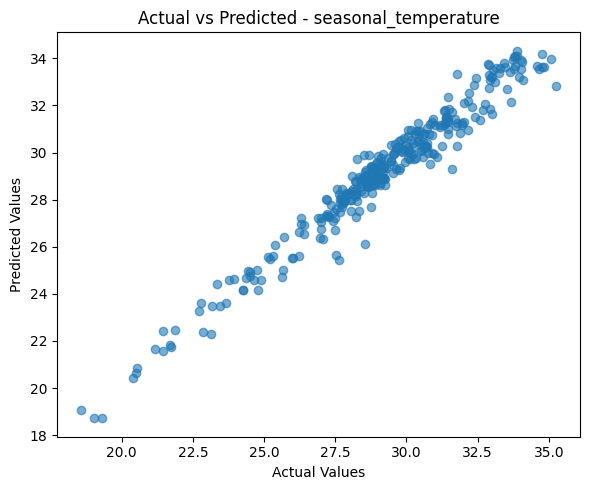

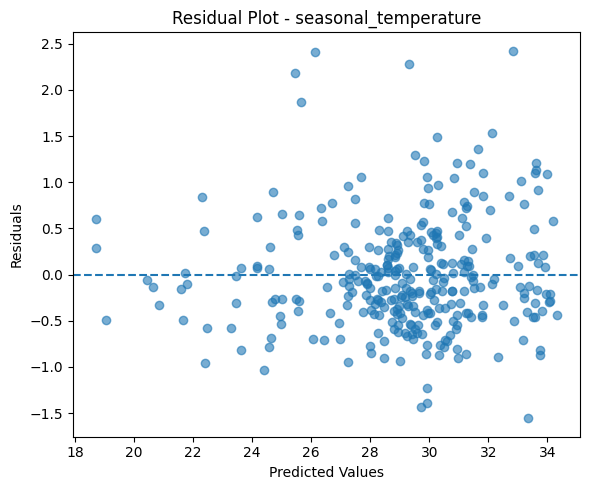

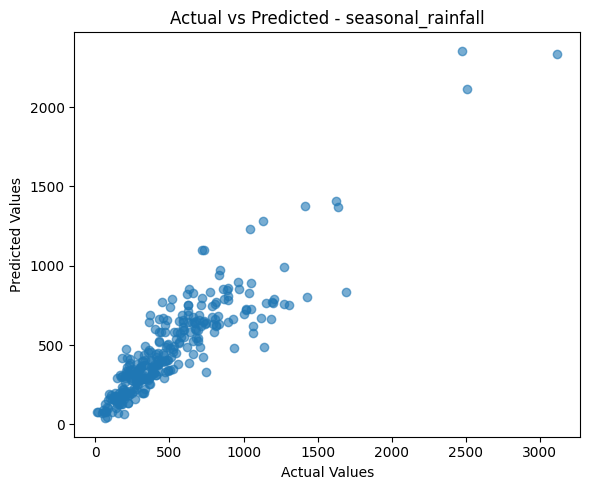

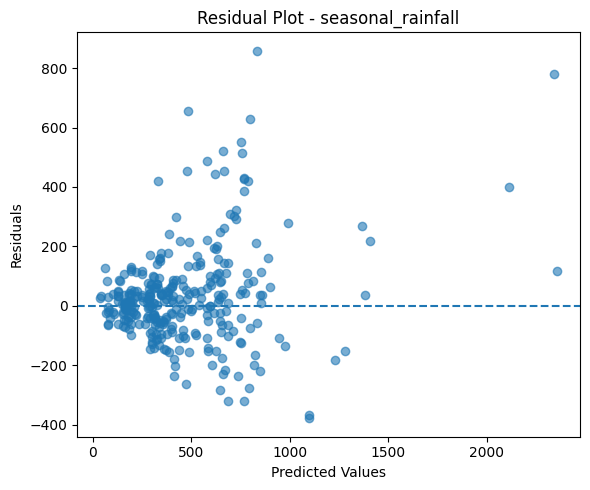

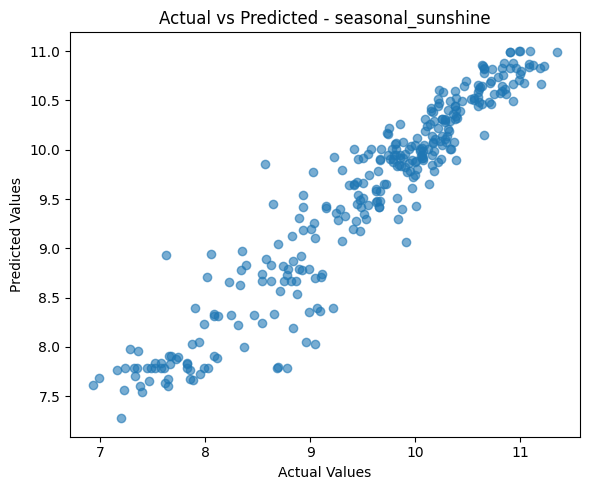

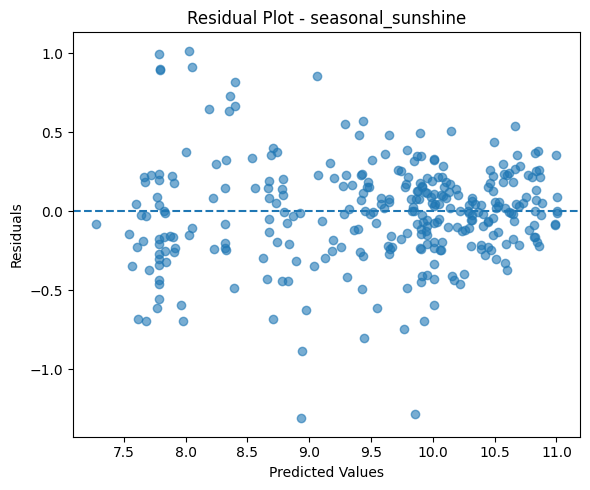

In [105]:
# =========================================================
# 12) PLOT ACTUAL VS PREDICTED FOR EACH MODEL
# =========================================================
for model_name, (X_test, y_test, y_pred) in results_cache.items():
    plt.figure(figsize=(6, 5))
    plt.scatter(y_test, y_pred, alpha=0.6)
    plt.xlabel("Actual Values")
    plt.ylabel("Predicted Values")
    plt.title(f"Actual vs Predicted - {model_name}")
    plt.tight_layout()
    plt.show()

    residuals = y_test - y_pred
    plt.figure(figsize=(6, 5))
    plt.scatter(y_pred, residuals, alpha=0.6)
    plt.axhline(0, linestyle="--")
    plt.xlabel("Predicted Values")
    plt.ylabel("Residuals")
    plt.title(f"Residual Plot - {model_name}")
    plt.tight_layout()
    plt.show()

In [106]:
# =========================================================
# 13) SAVE MODELS
# =========================================================
joblib.dump(models["seasonal_temperature"], "rf_seasonal_temperature.pkl")
joblib.dump(models["seasonal_rainfall"], "rf_seasonal_rainfall.pkl")
joblib.dump(models["seasonal_sunshine"], "rf_seasonal_sunshine.pkl")

metadata = {
    "date_col": DATE_COL,
    "location_col": LOC_COL,
    "season_definition": {
        "South-west monsoon": "May to September",
        "Intermonsoon after South-west monsoon": "October to November",
        "North-east monsoon": "December to February",
        "Intermonsoon after North-east monsoon": "March to April"
    },
    "features_used": [LOC_COL, "season", "year"],
    "targets": {
        "seasonal_temperature": "avg_temperature_C",
        "seasonal_rainfall": "log_total_rainfall_mm",
        "seasonal_sunshine": "avg_sunshine_h"
    },
    "metrics": metrics
}

joblib.dump(metadata, "rf_seasonal_weather_metadata.pkl")

with open("rf_seasonal_weather_metrics.json", "w") as f:
    json.dump(metrics, f, indent=4)

print("\nSaved files:")
print("- rf_seasonal_temperature.pkl")
print("- rf_seasonal_rainfall.pkl")
print("- rf_seasonal_sunshine.pkl")
print("- rf_seasonal_weather_metadata.pkl")
print("- rf_seasonal_weather_metrics.json")



Saved files:
- rf_seasonal_temperature.pkl
- rf_seasonal_rainfall.pkl
- rf_seasonal_sunshine.pkl
- rf_seasonal_weather_metadata.pkl
- rf_seasonal_weather_metrics.json


In [107]:
# =========================================================
# 14) EXAMPLE PREDICTION
# =========================================================
# Change these values as needed
example_input = pd.DataFrame({
    LOC_COL: ["1"],   # replace with a valid location value from your dataset
    "season": ["South-west monsoon"],
    "year": [2026]
})

pred_temp = models["seasonal_temperature"].predict(example_input)[0]
pred_rain = models["seasonal_rainfall"].predict(example_input)[0]
pred_sun = models["seasonal_sunshine"].predict(example_input)[0]

print("\nExample Seasonal Prediction")
print(example_input)
print(f"Predicted Seasonal Temperature (avg): {pred_temp:.2f} °C")
print(f"Predicted Seasonal Rainfall (total): {pred_rain:.2f} mm")
print(f"Predicted Seasonal Sunshine (avg): {pred_sun:.2f} h")



Example Seasonal Prediction
  location_id              season  year
0           1  South-west monsoon  2026
Predicted Seasonal Temperature (avg): 29.82 °C
Predicted Seasonal Rainfall (total): 7.00 mm
Predicted Seasonal Sunshine (avg): 8.94 h


In [108]:
# =========================================================
# 15) OPTIONAL FUNCTION FOR REUSE
# =========================================================
def predict_seasonal_weather(location_value, season_value, year_value):
    input_df = pd.DataFrame({
        LOC_COL: [str(location_value)],
        "season": [season_value],
        "year": [year_value]
    })

    return {
        "location": str(location_value),
        "season": season_value,
        "year": int(year_value),
        "predicted_avg_temperature_C": float(models["seasonal_temperature"].predict(input_df)[0]),
        "predicted_total_rainfall_mm": float(models["seasonal_rainfall"].predict(input_df)[0]),
        "predicted_avg_sunshine_h": float(models["seasonal_sunshine"].predict(input_df)[0])
    }


# Example function call
result = predict_seasonal_weather("1", "North-east monsoon", 2026)
print("\nReusable function output:")
print(result)


Reusable function output:
{'location': '1', 'season': 'North-east monsoon', 'year': 2026, 'predicted_avg_temperature_C': 31.866842257264178, 'predicted_total_rainfall_mm': 5.267329432965863, 'predicted_avg_sunshine_h': 9.894757521999257}
